# Telco Customer Churn Analysis

## 1. Introduction
The goal of this project is to analyze customer behavior and predict churn for a telecommunications company. Customer churn is a critical business problem, as retaining existing customers is more cost-effective than acquiring new ones. Using a combination of exploratory data analysis (EDA), churn pattern investigation, and machine learning models, this project examines which factors influence customer retention and develops predictive insights that can inform targeted retention strategies.

The analysis focuses on three key areas:

1. **Customer demographics and service usage** — understanding the composition of the customer base, including household structure, contract type, and service subscriptions.

1. **Churn patterns** — identifying which behavioral and demographic factors are associated with higher likelihood of leaving.

1. **Predictive modeling** — building a machine learning model to predict at-risk customers and provide actionable insights for retention efforts.

By combining descriptive analysis with predictive modeling, this project provides a comprehensive view of churn drivers and actionable recommendations for improving customer loyalty.

## 2. Dataset Overview

**Objective:** Review dataset structure, data types, and basic statistical insights.

### 2.1 Import Dataset

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score


# Load dataset

df = pd.read_csv('telco_customer_churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.2 Dataset Structure & Data Types

In [2]:
# Number of Rows and Columns

num_rows = df.shape[0]
num_columns = df.shape[1]

print(f'Dataset has {num_rows} rows and {num_columns} columns')

Dataset has 7043 rows and 21 columns


In [3]:
# Data Types, Null Values, Duplicates

print(df.dtypes, '\n')

print(f'The dataset has {df.isna().sum().sum()} null values and {df.duplicated().sum()} duplicates.')


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object 

The dataset has 0 null values and 0 duplicates.


### 2.3 Statistical Overview

In [4]:
df.describe(include = 'all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


### 3. Data Cleaning

**Objective:** Handle missing values, convert data types, and prepare categorical variables for analysis.

### 3.1 Data Type Correction

In [5]:
# Let's Fix the Mismatched Data Types

df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df.dtypes

customerID              str
gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

### 3.2 Null Values

In [6]:
# Coerce Turns Blank Strings into Nulls, So Let's Recheck

df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,No,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,No,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,No,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,No,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [7]:
# When Tenure is 0, Total Charges is Null - Let's Fix This

df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f'The dataset now has {df.isna().sum().sum()} null values and {df.duplicated().sum()} duplicates.')

The dataset now has 0 null values and 0 duplicates.


### 3.3 Conclusion
Now that our data is clean, we are now ready for analysis.

## 4. Exploratory Data Analysis (EDA)

**Objective:** Explore distributions of numerical and categorical variables to identify patterns before focusing on churn.

### 4.1 Contract Details Analysis

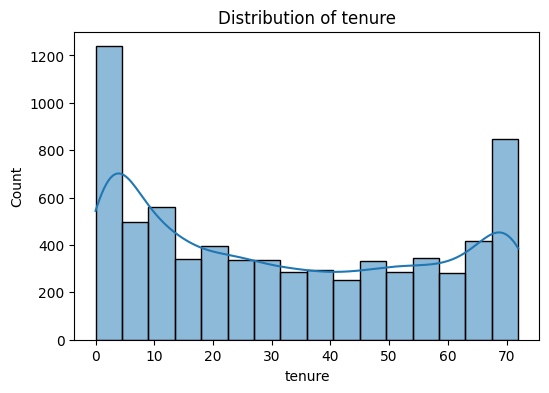

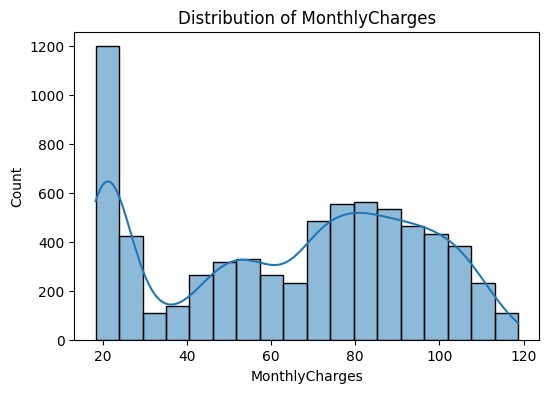

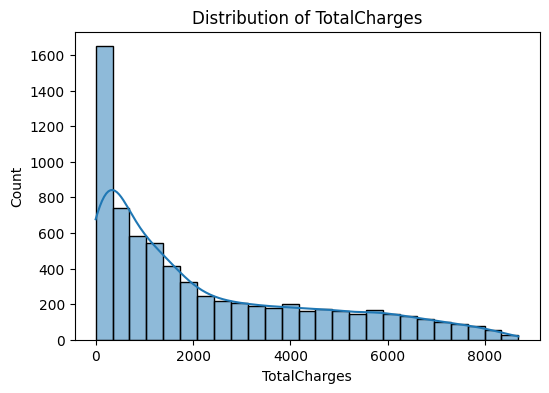

In [8]:
# Distribution of Numerical Columns

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

#### 4.1 Summary
- **Tenure**: A right-skewed distribution, with a large concentration of customers in the early months of their subscription. This suggests many relatively new customers in the dataset, which may be important when analyzing churn risk.

- **Monthly Charges**: Has multiple peaks, indicating the presence of different pricing tiers or service bundles. This suggests customer segmentation based on service level or add-ons.

- **Total Charges**: Heavily right-skewed, with a long tail of high values. This is expected, as customers with longer tenure accumulate higher total charges over time.

### 4.2 Customer Preference Analysis

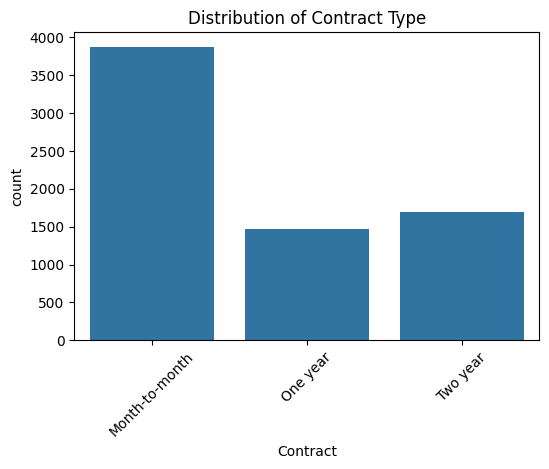

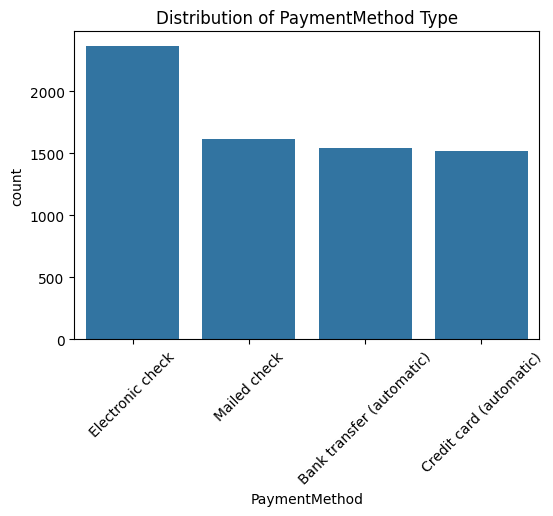

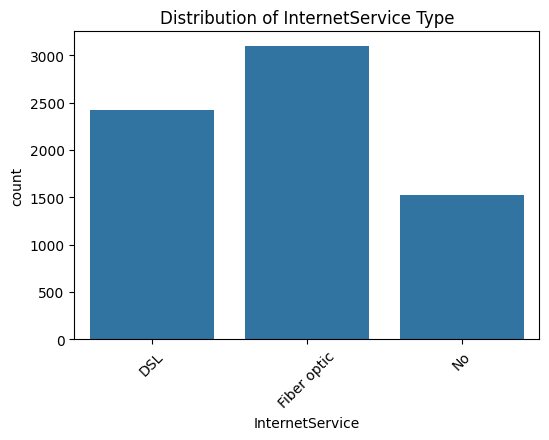

In [9]:
# Breakdown of Customer Preferences

categorical_cols = ['Contract', 'PaymentMethod', 'InternetService']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col} Type")
    plt.xticks(rotation=45)
    plt.show()

#### 4.2 Summary

- **Contract Type**: The majority of customers are on month-to-month contracts, with significantly fewer customers on one-year and two-year agreements. This indicates that a large portion of the customer base is not locked into long-term commitments, which may have implications for retention stability.

- **Payment Method**: Electronic check is the most commonly used payment method, followed by mailed check and automatic payment options. The distribution suggests a diverse set of payment behaviors, with a notable share of customers not enrolled in automatic billing.

- **Internet Service**: Fiber optic is the most common internet service type, followed by DSL, with a smaller segment having no internet service. This suggests that high-speed internet is a core offering for the majority of customers.

### 4.3 Customer Demographics Analysis

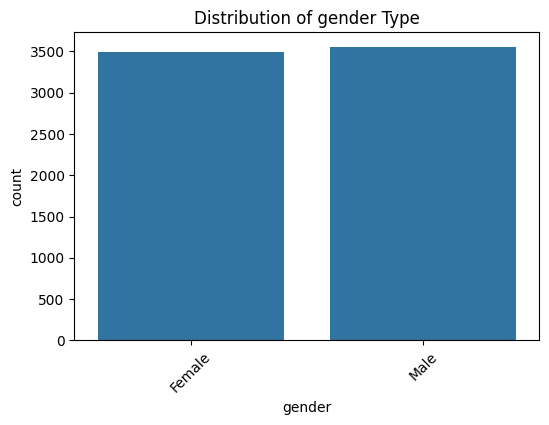

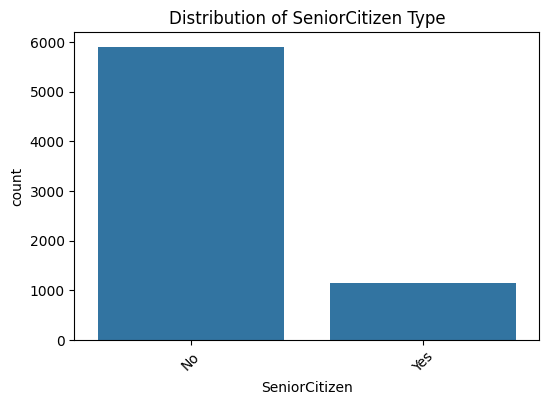

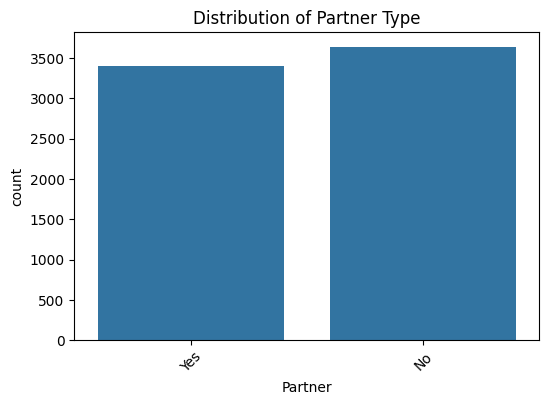

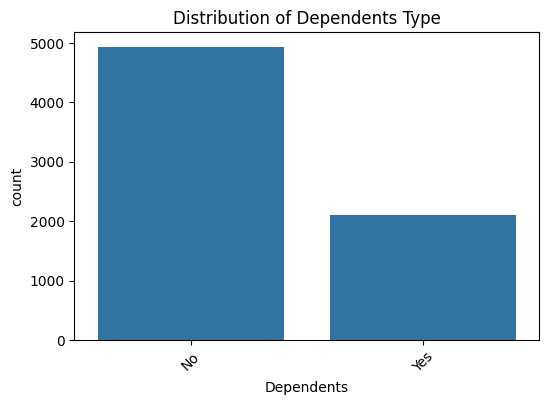

In [10]:
# Breakdown of Customer Demographics

customer_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
for col in customer_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col} Type")
    plt.xticks(rotation=45)
    plt.show()

#### 4.3 Summary

- **Gender**: The distribution between male and female customers is nearly balanced, indicating that gender is unlikely to be a primary differentiator for service usage or churn.

- **Senior Citizens**: A relatively small portion of the customer base are senior citizens. This suggests that retention strategies may need to focus more on younger or middle-aged segments, who form the bulk of the customer population.

- **Partner Status**: Roughly half of the customers have a partner and half do not, showing a fairly balanced distribution in household status.

- **Dependents**: Most customers do not have dependents, with a smaller segment having dependents. This indicates that the majority of subscribers are likely single or without family obligations, which could influence service preferences and engagement patterns.

### 4.4 EDA Conclusion
The dataset reflects a predominantly younger, flexible, and service-focused customer base, with substantial variation in revenue contribution. These patterns provide context for the subsequent churn analysis, emphasizing that contract type, service usage, and pricing tiers are likely to be key drivers of customer retention.

## 5. Churn Analysis

**Objective:** Explore what factors encourage and discourage customer retention.

### 5.1 Churn Analysis by Customer Preferences

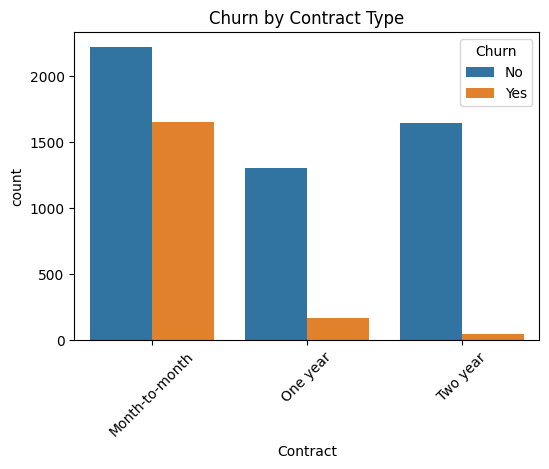

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [11]:
# Churn by Contract Type

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Churn by Contract Type")
plt.xticks(rotation=45)
plt.show()

contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn

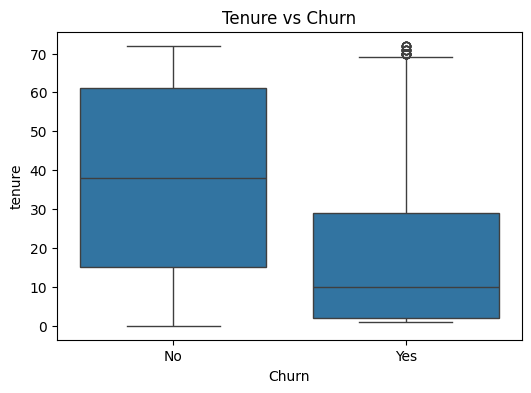

Churn,No,Yes
TenureGroup,,
0-1 yr,52.321839,47.678161
1-2 yrs,71.289062,28.710938
2-4 yrs,79.611041,20.388959
4-6 yrs,90.486824,9.513176


In [12]:
# Churn by Tenure

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

df['TenureGroup'] = pd.cut(df['tenure'],
                           bins=[0,12,24,48,72],
                           labels=['0-1 yr','1-2 yrs','2-4 yrs','4-6 yrs'])

pd.crosstab(df['TenureGroup'], df['Churn'], normalize='index') * 100

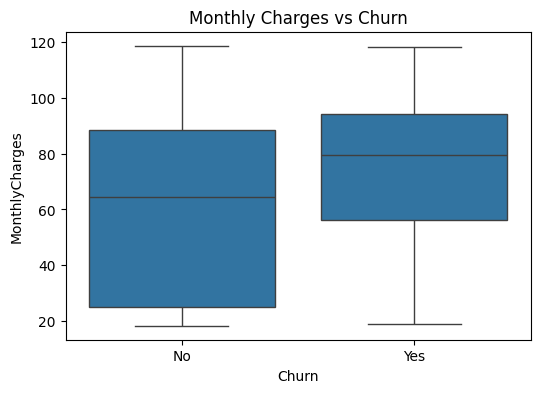

In [13]:
# Churn by Monthly Charges

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [14]:
# Churn by Internet Package

pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


#### 5.1 Summary

- **Contract Type**: Churn is highest among month-to-month customers and lowest for longer-term contracts, showing that longer commitments improve retention.

- **Tenure**: Customers who churn tend to have shorter tenure, while longer-tenured customers are much less likely to leave. Early-stage customers are the most at risk.

- **Internet Service**: Churn is higher among fiber optic users compared to DSL or customers without internet, suggesting that higher-tier or more complex services may carry greater churn risk.

### 5.2 Churn Analysis by Customer Demographics

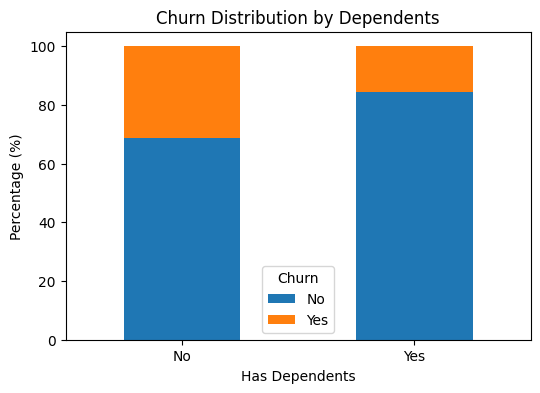

In [15]:
# Churn by Dependents

dependents_churn = pd.crosstab(
    df['Dependents'],
    df['Churn'],
    normalize='index'
) * 100

dependents_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(6,4)
)

plt.title("Churn Distribution by Dependents")
plt.ylabel("Percentage (%)")
plt.xlabel("Has Dependents")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

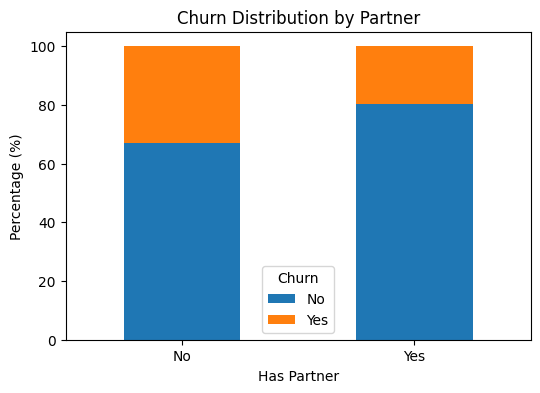

In [16]:
# Churn by Partner

partner_churn = pd.crosstab(
    df['Partner'],
    df['Churn'],
    normalize='index'
) * 100

partner_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(6,4)
)

plt.title("Churn Distribution by Partner")
plt.ylabel("Percentage (%)")
plt.xlabel("Has Partner")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

#### 5.2 Summary

- **Dependents**: Customers with dependents are less likely to churn compared to those without. This suggests that family obligations or household structures may contribute to higher retention.

- **Partner Status**: Similarly, customers with a partner have lower churn rates than those without, indicating that household stability may play a role in customer loyalty.

### 5.3 Churn Analysis Conclusion

Churn is influenced by both customer behavior and household characteristics. Short-term contracts, early tenure, and higher-tier services such as fiber optic are associated with higher churn, highlighting service and engagement related risk factors. Demographics also play a role - customers with partners or dependents are generally more loyal, suggesting that household stability contributes to retention.

**Overall Insight**: Retention strategies should prioritize early-stage, flexible-contract customers, particularly those using higher-tier services, while considering household context to further target higher-risk segments and maximize long-term customer value.

## 6. Basic Machine Learning: Predicting Customer Churn

**Objective:** Build a simple Logistic Regression classification model to predict customer churn.

### 6.1 Data Preprocessing

In [17]:
# Map Target and Features

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

X = df.drop('Churn', axis=1)
y = df['Churn']

if 'customerID' in X.columns:
    X = X.drop('customerID', axis=1)

In [18]:
# One-Hot Encoding

X = pd.get_dummies(X, drop_first=True)

### 6.2 Train/Test Split & Balance Evaluation

In [19]:
# 80/20 Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [20]:
# Evaluate Churn Balance

y.value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

### 6.3 Scaling, Training, Predicting

In [21]:
# Scaling Features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# Train Model

# Setting class weight to balanced to give more importance to the minority class when calculating the loss
log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [23]:
# Predictions

y_pred = log_model.predict(X_test_scaled)

### 6.4 Model Evaluation

In [24]:
# Accuracy and Roc Auc Score

accuracy = accuracy_score(y_test, y_pred)
y_prob = log_model.predict_proba(X_test_scaled)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)
print(f"Accuracy: {accuracy} \n Roc Auc Score: {roc_auc}")

Accuracy: 0.751596877217885 
 Roc Auc Score: 0.8600735453952613


In [25]:
# Classification Report.

print(f" Classification Report: \n {classification_report(y_test, y_pred)}")

 Classification Report: 
               precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.52      0.83      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.81      0.75      0.77      1409



### 6.5 Model Conclusion

The Logistic Regression model was trained to predict customer churn. Key performance metrics show that the model is effective at identifying at-risk customers while accounting for class imbalance:

- **Accuracy:** 75% — moderate overall accuracy, which is expected due to the imbalanced target (majority “No churn”). Accuracy alone is not fully informative in this context.

- **ROC-AUC:** 0.86 — indicates strong overall ability to distinguish between churned and retained customers.

- **Precision and Recall:**

    - For churned customers (“Yes”), recall is high (0.83), meaning the model correctly identifies the majority of customers who will churn.

    - Precision for churned customers is lower (0.52), showing that some predicted churners may not actually leave.

    - For non-churned customers (“No”), precision is very high (0.92) but recall is lower (0.72), reflecting the trade-off from prioritizing churn detection.

- **F1 Score:** Balances precision and recall for each class. The F1 score for churn (“Yes”) is 0.64, indicating reasonable balance in capturing churners without overwhelming false positives.

**Overall Insight:** The model is tuned to **prioritize recall for churned customers**, which aligns with the business goal of identifying at-risk customers for retention efforts. While some false positives occur, the model effectively highlights the most critical segments to target, and the high ROC-AUC shows it reliably distinguishes between churners and non-churners.

## 7. Overall Project Summary and Business Recommendations

### 7.1 Dataset and EDA Insights

- The dataset reflects a **predominantly flexible and service-focused customer base,** with most customers subscribing to month-to-month contracts and fiber optic internet services.

- Demographics such as age, gender, partner status, and dependents show some influence on behavior, but **service-related features and tenure** are the strongest differentiators for revenue and churn risk.

- Tenure is right-skewed, with many new customers, highlighting the importance of early engagement for retention.

### 7.2 Churn Analysis

- **Behavioral drivers:** Customers on **short-term contracts,** with **early tenure,** or using **higher-tier services** like fiber optic are at **highest risk of churn.**

- **Demographic drivers:** Customers with **partners or dependents** are generally more loyal, indicating that household stability contributes to retention.

- **Overall insight:** Both service usage and household characteristics influence churn, but engagement and contract structure are the strongest levers for retention strategies.

### 7.3 Machine Learning Performance

- A **Logistic Regression model** was trained to predict churn. Key metrics show:

    - **ROC-AUC = 0.86** — strong overall ability to distinguish churners.

    - **Recall for churned customers = 0.83** — most at-risk customers are correctly identified.

    - **Precision for churned customers = 0.52**, F1 = 0.64 — some false positives, but trade-offs favor identifying churners.

- The model is tuned to **prioritize recall for churn,** aligning with the business objective of proactive retention.

### 7.4 Business Recommendations

1. **Focus retention efforts on early-stage, month-to-month customers,** especially those using high-tier services like fiber optic. Early interventions, such as personalized offers or engagement campaigns, are likely to have the highest impact.

1. **Leverage household information** — customers with partners or dependents are more loyal, so single or non-family households may require additional incentives or targeted engagement.

1. **Consider contract incentives** — encouraging one or two-year contracts can reduce churn risk, as longer-term commitments correlate strongly with retention.

1. **Monitor high-risk service segments** — fiber optic users churn more than DSL or non-internet customers; investigate service satisfaction or billing issues in these segments.

1. **Use predictive modeling to guide interventions** — the machine learning model can help identify at-risk customers for proactive outreach, maximizing retention ROI.